<a href="https://colab.research.google.com/github/omnimbalkar9730/AI-Based-Smart-hand-Gesture-Recongnition-for-Elderly-and-Disabled-Assistance/blob/main/EMG_Gesture_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMG Gesture Classification Pipeline

This notebook builds a complete pipeline for gesture classification from the uploaded
`archive.zip` dataset:

1. **Load** the zip (sEMG + pFMG recordings, 3 sub-datasets, multiple subjects)
2. **Segment** continuous recordings into trials and sliding windows
3. **Filter** the raw sEMG (band-pass + 50 Hz notch)
4. **Extract features**: time-domain, frequency-domain, and time-frequency (wavelet) domain
5. **Classify** gestures with classical ML (Random Forest, SVM) **and** a 1D CNN on raw windows
6. **Compare** results and save the trained models

### Dataset structure (auto-detected from `archive.zip`)

```
ConditionIndex/   -> per-trial arm-position / transition labels (Dataset2 & 3)
Dataset1/          -> D1_S<subject>.npy  -> shape (n_gestures=7,  16 channels, time)   fs=1000 Hz
Dataset2/          -> D2_S<subject>.npy  -> shape (n_gestures=9,  16 channels, time)   fs=2000 Hz
Dataset3/          -> D3_S<subject>.npy  -> shape (n_gestures=9,  16 channels, time)   fs=2000 Hz
Metadata/          -> gesture_labels.csv, channel_map.csv, participants.csv, acquisition_parameters.json ...
TrialIndex/         -> per-gesture (start,end) sample indices of each fixed-length trial
```

Each `.npy` array is `(gesture, channel, time)` where the time axis is simply the
concatenation of that gesture's trials (all trials have equal, fixed length — confirmed
against `TrialIndex`). The 16 channels are **interleaved sEMG/pFMG pairs**
(`channel_map.csv`): even indices (0,2,4,...) = sEMG, odd indices (1,3,5,...) = pFMG
(force-myography). This notebook uses the **8 sEMG channels** for gesture classification
by default — set `USE_PFMG = True` below to also include the 8 pFMG channels.

> Only `Dataset1`, `Dataset2` and `Dataset3` folders are used for classification.
> `code/` contains the original authors' scripts and is not needed here.


## 1. Setup

In [ ]:
# pywt = wavelet transforms (time-frequency features). Everything else ships with Colab.
!pip install -q pywt PyWavelets 2>/dev/null
!pip install -q PyWavelets


In [ ]:
import os, re, glob, json, zipfile, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt, iirnotch, welch
from scipy.stats import skew, kurtosis
import pywt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load the dataset zip from Downloads

Run the cell below and use the file picker to upload `archive.zip` from your computer's
Downloads folder. If you've already uploaded it to `/content/archive.zip` (e.g. by
dragging it into the Colab file browser, or it's on Google Drive), the cell will detect
and reuse it instead of prompting again.

In [ ]:
ZIP_PATH = "/content/archive.zip"
DATA_ROOT = "/content/emg_data"

if not os.path.exists(ZIP_PATH):
    try:
        from google.colab import files
        print("Please choose archive.zip from your Downloads folder...")
        uploaded = files.upload()
        # Grab whatever zip was uploaded
        zip_name = [f for f in uploaded.keys() if f.lower().endswith(".zip")][0]
        os.rename(zip_name, ZIP_PATH)
    except ImportError:
        raise FileNotFoundError(
            f"{ZIP_PATH} not found and google.colab isn't available. "
            "Place archive.zip at this path manually."
        )
else:
    print(f"Found existing zip at {ZIP_PATH}, skipping upload.")

print("Zip size (MB):", round(os.path.getsize(ZIP_PATH)/1e6, 1))


Please choose archive.zip from your Downloads folder...


Saving archive (1).zip to archive (1).zip
Zip size (MB): 81.2


In [ ]:
os.makedirs(DATA_ROOT, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(DATA_ROOT)

for root, dirs, fnames in os.walk(DATA_ROOT):
    depth = root.replace(DATA_ROOT, '').count(os.sep)
    if depth <= 1:
        print(root, '->', len(fnames), 'files')


/content/emg_data -> 1 files
/content/emg_data/ConditionIndex -> 2 files
/content/emg_data/Dataset1 -> 14 files
/content/emg_data/TrialIndex -> 16 files
/content/emg_data/Dataset3 -> 11 files
/content/emg_data/Metadata -> 13 files
/content/emg_data/code -> 2 files
/content/emg_data/Dataset2 -> 10 files


## 3. Configuration

Acquisition parameters (sampling rate, trial length, gesture count) come from
`Metadata/acquisition_parameters.json`, which we read directly rather than hard-coding,
so the pipeline stays correct even if the file counts change.

In [ ]:
with open(os.path.join(DATA_ROOT, "Metadata", "acquisition_parameters.json")) as f:
    ACQ_PARAMS = json.load(f)

print(json.dumps(ACQ_PARAMS, indent=2))


{
  "Dataset1": {
    "description": "Static position dataset",
    "sampling_rate_hz": 1000,
    "trial_duration_seconds": 2,
    "samples_per_trial": 2000,
    "n_gestures": 7,
    "repetitions_per_gesture": "8\u20139 (subject-dependent)",
    "sEMG_analogue_filtering": {
      "highpass_hz": 20,
      "lowpass_hz": 150,
      "notch_hz": 50
    },
    "pFMG_filtering": "none"
  },
  "Dataset2": {
    "description": "Static multi-position dataset with cyclic arm position changes",
    "sampling_rate_hz": 2000,
    "trial_duration_seconds": 1,
    "samples_per_trial": 2000,
    "n_gestures": 9,
    "n_arm_positions": 3,
    "arm_positions": [
      "P1",
      "P2",
      "P3"
    ],
    "repetition_structure": {
      "repetitions_per_position": 4,
      "position_cycle": [
        "P1",
        "P2",
        "P3"
      ],
      "n_position_cycles": 3,
      "total_trials_per_gesture": 12
    },
    "trial_definition": {
      "static_trials": "fixed-length raw recording at a fixed a

In [ ]:
# Filtering bands: Dataset1's analogue front-end is specified explicitly
# (20-150 Hz band-pass, 50 Hz notch). Dataset2/3 don't specify one, so we use the
# standard surface-EMG band (20-450 Hz), safely below their 2000 Hz Nyquist (1000 Hz).
DATASET_CONFIGS = {
    "Dataset1": dict(folder="Dataset1", prefix="D1",
                      fs=ACQ_PARAMS["Dataset1"]["sampling_rate_hz"],
                      samples_per_trial=ACQ_PARAMS["Dataset1"]["samples_per_trial"],
                      gesture_csv="dataset1_gesture_list.csv",
                      bp_low=20, bp_high=150, notch=50),
    "Dataset2": dict(folder="Dataset2", prefix="D2",
                      fs=ACQ_PARAMS["Dataset2"]["sampling_rate_hz"],
                      samples_per_trial=ACQ_PARAMS["Dataset2"]["samples_per_trial"],
                      gesture_csv="dataset2_gesture_list.csv",
                      bp_low=20, bp_high=450, notch=50),
    "Dataset3": dict(folder="Dataset3", prefix="D3",
                      fs=ACQ_PARAMS["Dataset3"]["sampling_rate_hz"],
                      samples_per_trial=ACQ_PARAMS["Dataset3"]["samples_per_trial"],
                      gesture_csv="dataset3_gesture_list.csv",
                      bp_low=20, bp_high=450, notch=50),
}

# channel_map.csv: even channel index = sEMG, odd = pFMG (colocated pairs)
SEMG_CHANNELS = list(range(0, 16, 2))
PFMG_CHANNELS = list(range(1, 16, 2))

# ---- choose what to run -------------------------------------------------
DATASET_KEY = "Dataset1"   # "Dataset1" | "Dataset2" | "Dataset3"
USE_PFMG    = False        # include the 8 pFMG (force) channels alongside sEMG
WIN_MS      = 200          # analysis window length (ms)
STEP_MS     = 100          # window step / hop (ms) -> 50% overlap
MAX_SUBJECTS = None        # set an int to subsample subjects for a quick test run
# ---------------------------------------------------------------------

cfg = DATASET_CONFIGS[DATASET_KEY]
CHANNELS = SEMG_CHANNELS + (PFMG_CHANNELS if USE_PFMG else [])
gesture_df = pd.read_csv(os.path.join(DATA_ROOT, "Metadata", cfg["gesture_csv"]))
GESTURE_NAMES = dict(zip(gesture_df.gesture_index, gesture_df.gesture_name))
print(cfg)
print("Gestures:", GESTURE_NAMES)
print("Channels used:", CHANNELS)


{'folder': 'Dataset1', 'prefix': 'D1', 'fs': 1000, 'samples_per_trial': 2000, 'gesture_csv': 'dataset1_gesture_list.csv', 'bp_low': 20, 'bp_high': 150, 'notch': 50}
Gestures: {0: 'relax', 1: 'open', 2: 'fist', 3: 'tripod', 4: 'key', 5: 'pronation', 6: 'supination'}
Channels used: [0, 2, 4, 6, 8, 10, 12, 14]


## 4. Load raw recordings and split into fixed-length trials

In [ ]:
def list_subject_files(cfg):
    pattern = os.path.join(DATA_ROOT, cfg["folder"], f"{cfg['prefix']}_S*.npy")
    files = sorted(glob.glob(pattern),
                    key=lambda f: int(re.search(r'_S(\d+)\.npy$', f).group(1)))
    subj_ids = [int(re.search(r'_S(\d+)\.npy$', f).group(1)) for f in files]
    return files, subj_ids

def load_trials(filepath, samples_per_trial):
    """Load one subject's .npy and reshape into (gesture, trial, channel, time)."""
    arr = np.load(filepath).astype(np.float64)          # (gesture, channel, total_time)
    n_gestures, n_ch, total_samples = arr.shape
    n_trials = total_samples // samples_per_trial
    trials = arr[:, :, :n_trials*samples_per_trial]
    trials = trials.reshape(n_gestures, n_ch, n_trials, samples_per_trial)
    trials = trials.transpose(0, 2, 1, 3)                # -> (gesture, trial, channel, time)
    return trials

files, subj_ids = list_subject_files(cfg)
if MAX_SUBJECTS:
    files, subj_ids = files[:MAX_SUBJECTS], subj_ids[:MAX_SUBJECTS]

print(f"{DATASET_KEY}: {len(files)} subjects -> {subj_ids}")

example_trials = load_trials(files[0], cfg["samples_per_trial"])
print("Example subject trial array shape (gesture, trial, channel, time):", example_trials.shape)


Dataset1: 14 subjects -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Example subject trial array shape (gesture, trial, channel, time): (7, 9, 16, 2000)


### Quick sanity check: raw signal per gesture

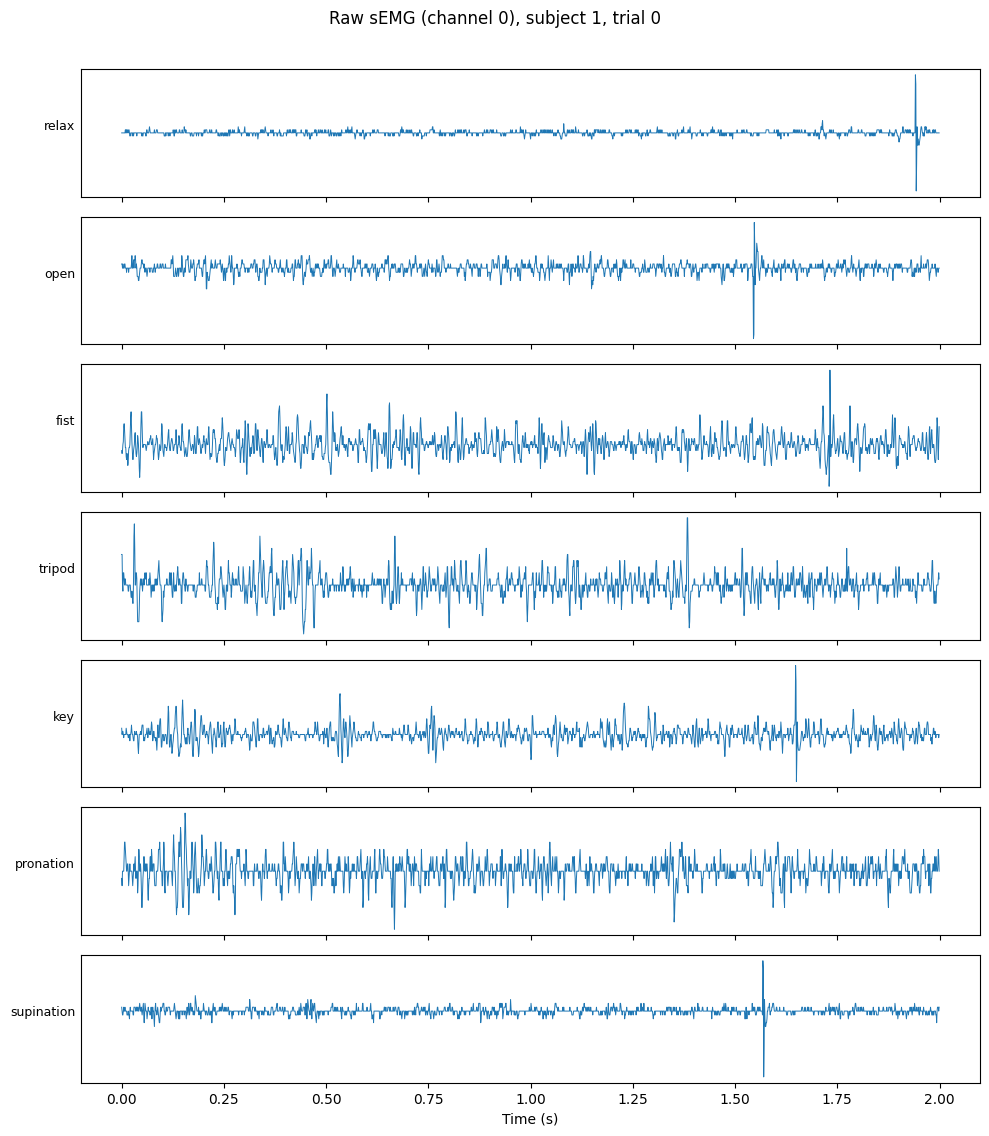

In [ ]:
fig, axes = plt.subplots(len(GESTURE_NAMES), 1, figsize=(10, 1.6*len(GESTURE_NAMES)), sharex=True)
t_axis = np.arange(cfg["samples_per_trial"]) / cfg["fs"]
for g, ax in zip(sorted(GESTURE_NAMES), axes):
    ax.plot(t_axis, example_trials[g, 0, SEMG_CHANNELS[0]], lw=0.7)
    ax.set_ylabel(GESTURE_NAMES[g], rotation=0, ha='right', fontsize=9)
    ax.set_yticks([])
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Raw sEMG (channel {SEMG_CHANNELS[0]}), subject {subj_ids[0]}, trial 0", y=1.01)
plt.tight_layout()
plt.show()


## 5. Filtering

Standard sEMG conditioning: 4th-order Butterworth band-pass (removes motion artefact
and high-frequency noise) followed by a 50 Hz notch (mains interference), both applied
zero-phase with `filtfilt`. pFMG channels (if used) are left unfiltered — they're a slow
force signal, not an electrical one, and the acquisition metadata explicitly lists their
filtering as `"none"`.

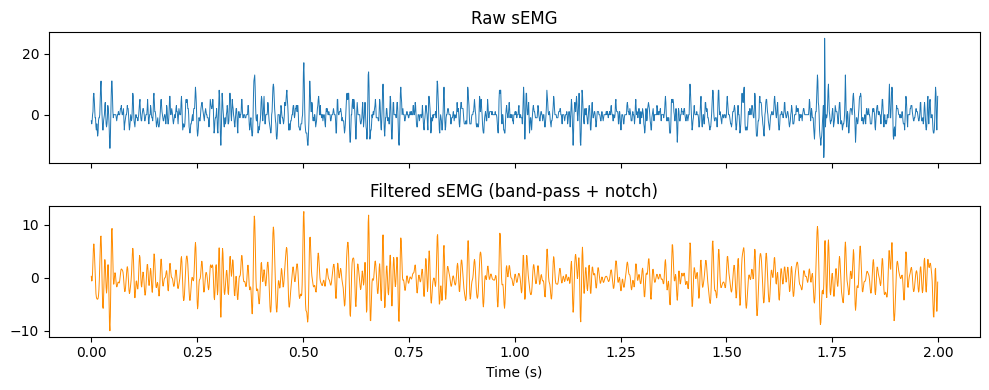

In [ ]:
def bandpass_filter(sig, low, high, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, min(high/nyq, 0.99)], btype="band")
    return filtfilt(b, a, sig)

def notch_filter(sig, freq, fs, quality=30):
    nyq = 0.5 * fs
    b, a = iirnotch(freq/nyq, quality)
    return filtfilt(b, a, sig)

def filter_semg(sig, cfg):
    sig = bandpass_filter(sig, cfg["bp_low"], cfg["bp_high"], cfg["fs"])
    sig = notch_filter(sig, cfg["notch"], cfg["fs"])
    return sig

# visualize before/after on one trial/channel
raw_sig = example_trials[2, 0, SEMG_CHANNELS[0]]
filt_sig = filter_semg(raw_sig, cfg)

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].plot(t_axis, raw_sig, lw=0.7); axes[0].set_title("Raw sEMG")
axes[1].plot(t_axis, filt_sig, lw=0.7, color="darkorange"); axes[1].set_title("Filtered sEMG (band-pass + notch)")
axes[1].set_xlabel("Time (s)")
plt.tight_layout(); plt.show()


## 6. Segmentation

Each trial (2000 samples) is cut into overlapping analysis windows using a sliding
window — the standard approach for EMG gesture recognition, since it both increases the
number of training examples and matches how a real-time system would process a
continuous stream.

In [ ]:
WIN_LEN  = int(WIN_MS  / 1000 * cfg["fs"])
STEP_LEN = int(STEP_MS / 1000 * cfg["fs"])
print(f"Window length: {WIN_LEN} samples ({WIN_MS} ms) | step: {STEP_LEN} samples ({STEP_MS} ms)")

def segment_signal(x, win, step):
    """x: (channels, time) -> (n_windows, channels, win)"""
    n = x.shape[-1]
    starts = range(0, n - win + 1, step)
    return np.stack([x[..., s:s+win] for s in starts], axis=0)


Window length: 200 samples (200 ms) | step: 100 samples (100 ms)


## 7. Feature extraction

Three families of hand-crafted features are computed **per channel, per window** (used
by the classical ML models below). The same filtered windows (in raw form) are reused
directly as input to the 1D CNN, so filtering/segmentation is only done once.

- **Time domain**: MAV, RMS, Waveform Length, Variance, Zero Crossings, Slope Sign
  Changes, Willison Amplitude, Integrated EMG, Skewness, Kurtosis
- **Frequency domain** (Welch PSD): Mean Frequency, Median Frequency, Peak Frequency,
  Total Power, low/high-band Frequency Ratio
- **Time-frequency domain** (Discrete Wavelet Transform, `db4`, 4 levels): per-level
  detail-coefficient energy & Shannon entropy, plus final approximation energy

In [ ]:
def time_domain_features(x):
    zc_thresh, ssc_thresh, wamp_thresh = 1e-3, 1e-3, 1e-2
    d = np.diff(x)
    zc = np.sum((x[:-1]*x[1:] < 0) & (np.abs(d) > zc_thresh))
    d1, d2 = x[1:-1]-x[:-2], x[1:-1]-x[2:]
    ssc = np.sum((d1*d2) > ssc_thresh)
    return {
        "MAV":  np.mean(np.abs(x)),
        "RMS":  np.sqrt(np.mean(x**2)),
        "WL":   np.sum(np.abs(d)),
        "VAR":  np.var(x),
        "ZC":   zc,
        "SSC":  ssc,
        "WAMP": np.sum(np.abs(d) > wamp_thresh),
        "IEMG": np.sum(np.abs(x)),
        "SKEW": skew(x),
        "KURT": kurtosis(x),
    }

def freq_domain_features(x, fs):
    freqs, psd = welch(x, fs=fs, nperseg=min(len(x), 128))
    total_power = np.sum(psd) + 1e-12
    mnf = np.sum(freqs * psd) / total_power
    mdf = freqs[np.searchsorted(np.cumsum(psd), total_power/2)]
    peak_f = freqs[np.argmax(psd)]
    low_band  = np.sum(psd[freqs < fs/4])
    high_band = np.sum(psd[freqs >= fs/4]) + 1e-12
    return {"MNF": mnf, "MDF": mdf, "PEAKF": peak_f, "TOTP": total_power, "FR": low_band/high_band}

def wavelet_features(x, wavelet="db4", level=4):
    max_level = pywt.dwt_max_level(len(x), pywt.Wavelet(wavelet).dec_len)
    level = min(level, max_level)
    coeffs = pywt.wavedec(x, wavelet, level=level)   # [cA_n, cD_n, ..., cD_1]
    approx, details = coeffs[0], coeffs[1:]
    feats = {}
    for i, cD in enumerate(details, start=1):
        energy = np.sum(cD**2)
        p = cD**2 / (np.sum(cD**2) + 1e-12)
        entropy = -np.sum(p * np.log(p + 1e-12))
        feats[f"D{i}_energy"] = energy
        feats[f"D{i}_entropy"] = entropy
    feats[f"A{level}_energy"] = np.sum(approx**2)
    return feats

def extract_window_features(window, fs):
    """window: (channels, time) -> flat dict of features across all channels"""
    row = {}
    for ch in range(window.shape[0]):
        x = window[ch]
        for k, v in time_domain_features(x).items():   row[f"ch{ch}_{k}"] = v
        for k, v in freq_domain_features(x, fs).items(): row[f"ch{ch}_{k}"] = v
        for k, v in wavelet_features(x).items():         row[f"ch{ch}_{k}"] = v
    return row


## 8. Build the full windowed dataset

Single pass over every subject / gesture / trial: filter -> segment -> for each window,
keep the **raw filtered window** (for the CNN) and compute the **feature vector** (for
classical ML). `subject_ids` are kept alongside the labels so you can optionally
evaluate subject-independent generalization later.

In [ ]:
X_raw, X_feat_rows, y, groups = [], [], [], []

for fpath, sid in zip(files, subj_ids):
    trials = load_trials(fpath, cfg["samples_per_trial"])   # (gesture, trial, channel, time)
    n_gestures, n_trials = trials.shape[0], trials.shape[1]
    for g in range(n_gestures):
        for t in range(n_trials):
            sig = trials[g, t][CHANNELS, :]                  # (n_channels, time)
            filt = np.array([
                filter_semg(ch, cfg) if idx in SEMG_CHANNELS else ch
                for idx, ch in zip(CHANNELS, sig)
            ])
            windows = segment_signal(filt, WIN_LEN, STEP_LEN)  # (n_win, n_channels, WIN_LEN)
            for w in windows:
                X_raw.append(w)
                X_feat_rows.append(extract_window_features(w, cfg["fs"]))
                y.append(g)
                groups.append(sid)
    print(f"subject {sid}: done ({len(y)} windows so far)")

X_raw = np.array(X_raw)                     # (N, n_channels, WIN_LEN)
X_feat = pd.DataFrame(X_feat_rows)          # (N, n_channels * n_features)
y = np.array(y)
groups = np.array(groups)

print("\nRaw windows:", X_raw.shape)
print("Feature matrix:", X_feat.shape)
print("Label distribution:\n", pd.Series(y).map(GESTURE_NAMES).value_counts())


subject 1: done (1197 windows so far)
subject 2: done (2261 windows so far)
subject 3: done (3458 windows so far)
subject 4: done (4522 windows so far)
subject 5: done (5586 windows so far)
subject 6: done (6783 windows so far)
subject 7: done (7980 windows so far)
subject 8: done (9177 windows so far)
subject 9: done (10374 windows so far)
subject 10: done (11571 windows so far)
subject 11: done (12768 windows so far)
subject 12: done (13965 windows so far)
subject 13: done (15162 windows so far)
subject 14: done (16359 windows so far)

Raw windows: (16359, 8, 200)
Feature matrix: (16359, 192)
Label distribution:
 relax         2337
open          2337
fist          2337
tripod        2337
key           2337
pronation     2337
supination    2337
Name: count, dtype: int64


## 9. Train / test split

A stratified random split is used by default (keeps class balance). If you want a
stricter **subject-independent** evaluation (train on some subjects, test on others,
which is harder and more realistic), switch `SPLIT_MODE` to `"group"`.

In [ ]:
SPLIT_MODE = "stratified"   # "stratified" | "group"
TEST_SIZE = 0.2

if SPLIT_MODE == "group":
    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=42)
    train_idx, test_idx = next(gss.split(X_feat, y, groups))
else:
    train_idx, test_idx = train_test_split(
        np.arange(len(y)), test_size=TEST_SIZE, stratify=y, random_state=42
    )

Xf_train, Xf_test = X_feat.values[train_idx], X_feat.values[test_idx]
Xr_train, Xr_test = X_raw[train_idx], X_raw[test_idx]
y_train, y_test   = y[train_idx], y[test_idx]

print(f"Split mode: {SPLIT_MODE} | train: {len(train_idx)} | test: {len(test_idx)}")


Split mode: stratified | train: 13087 | test: 3272


## 10. Classical ML: Random Forest & SVM

Hand-crafted features are standardized, then fed to a Random Forest and an RBF-kernel
SVM. Both are solid, fast baselines for EMG feature-based gesture classification.

In [ ]:
scaler = StandardScaler().fit(Xf_train)
Xf_train_s = scaler.transform(Xf_train)
Xf_test_s  = scaler.transform(Xf_test)

results = {}

rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(Xf_train_s, y_train)
rf_pred = rf.predict(Xf_test_s)
results["Random Forest"] = accuracy_score(y_test, rf_pred)

svm = SVC(kernel="rbf", C=10, gamma="scale")
svm.fit(Xf_train_s, y_train)
svm_pred = svm.predict(Xf_test_s)
results["SVM (RBF)"] = accuracy_score(y_test, svm_pred)

for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

print("\n--- Random Forest report ---")
print(classification_report(y_test, rf_pred, target_names=[GESTURE_NAMES[i] for i in sorted(GESTURE_NAMES)]))


Random Forest: 0.9273
SVM (RBF): 0.8860

--- Random Forest report ---
              precision    recall  f1-score   support

       relax       0.92      0.98      0.95       467
        open       0.95      0.96      0.95       467
        fist       0.92      0.95      0.94       467
      tripod       0.91      0.92      0.92       468
         key       0.89      0.87      0.88       468
   pronation       0.97      0.94      0.95       467
  supination       0.94      0.87      0.90       468

    accuracy                           0.93      3272
   macro avg       0.93      0.93      0.93      3272
weighted avg       0.93      0.93      0.93      3272



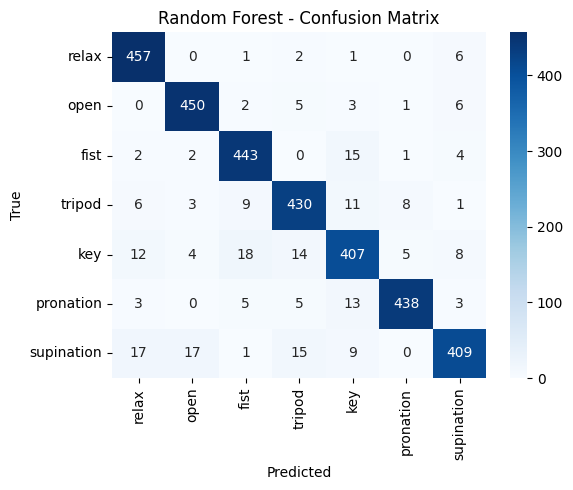

In [ ]:
def plot_confusion(y_true, y_pred, title):
    labels = sorted(GESTURE_NAMES)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[GESTURE_NAMES[l] for l in labels],
                yticklabels=[GESTURE_NAMES[l] for l in labels])
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()

plot_confusion(y_test, rf_pred, "Random Forest - Confusion Matrix")


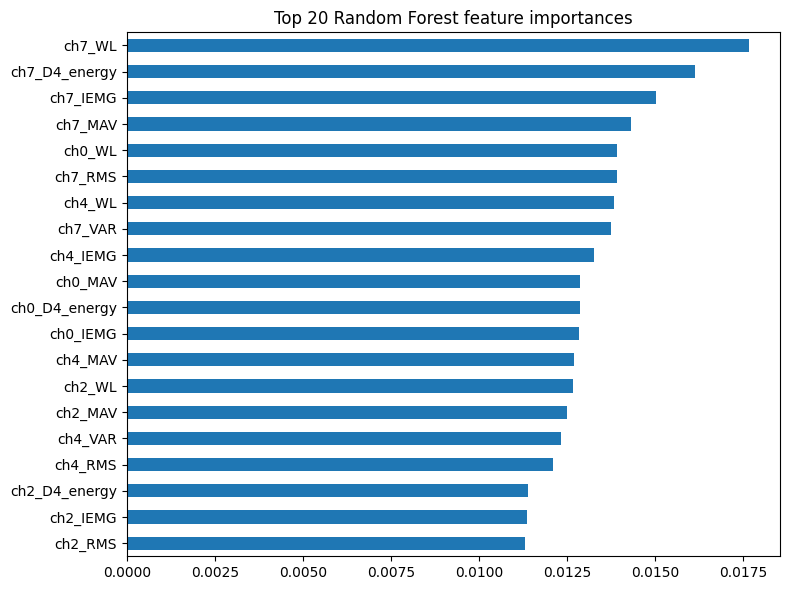

In [ ]:
# Top feature importances
importances = pd.Series(rf.feature_importances_, index=X_feat.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
importances.head(20).iloc[::-1].plot(kind="barh")
plt.title("Top 20 Random Forest feature importances")
plt.tight_layout(); plt.show()


## 11. Deep Learning: 1D CNN on raw filtered windows

The CNN skips hand-crafted features entirely and learns directly from the filtered,
segmented multi-channel time series (`channels last` format: `(window_length,
n_channels)`), which is the standard input layout for `Conv1D` in Keras.

In [ ]:
le = LabelEncoder().fit(y_train)
yc_train = le.transform(y_train)
yc_test  = le.transform(y_test)
n_classes = len(le.classes_)

# (N, channels, time) -> (N, time, channels) for Conv1D, then per-channel z-score
Xc_train = Xr_train.transpose(0, 2, 1)
Xc_test  = Xr_test.transpose(0, 2, 1)

ch_mean = Xc_train.mean(axis=(0, 1), keepdims=True)
ch_std  = Xc_train.std(axis=(0, 1), keepdims=True) + 1e-8
Xc_train = (Xc_train - ch_mean) / ch_std
Xc_test  = (Xc_test  - ch_mean) / ch_std

print("CNN input shape:", Xc_train.shape, "-> (samples, time, channels)")


CNN input shape: (13087, 200, 8) -> (samples, time, channels)


In [ ]:
def build_cnn(input_shape, n_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(32, kernel_size=5, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(64, kernel_size=5, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(128, kernel_size=3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

cnn = build_cnn(Xc_train.shape[1:], n_classes)
cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 32)        │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,927 (179.40 KB)

 Trainable params: 45,479 (177.65 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
early_stop = callbacks.EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True)
reduce_lr  = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5)

history = cnn.fit(
    Xc_train, yc_train,
    validation_split=0.15,
    epochs=60,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=2,
)


Epoch 1/60
174/174 - 13s - 72ms/step - accuracy: 0.4644 - loss: 1.4045 - val_accuracy: 0.3035 - val_loss: 1.8403 - learning_rate: 0.0010
Epoch 2/60
174/174 - 1s - 5ms/step - accuracy: 0.6248 - loss: 1.0247 - val_accuracy: 0.6146 - val_loss: 1.0212 - learning_rate: 0.0010
Epoch 3/60
174/174 - 1s - 5ms/step - accuracy: 0.6831 - loss: 0.8521 - val_accuracy: 0.7347 - val_loss: 0.7281 - learning_rate: 0.0010
Epoch 4/60
174/174 - 1s - 5ms/step - accuracy: 0.7296 - loss: 0.7452 - val_accuracy: 0.7663 - val_loss: 0.6442 - learning_rate: 0.0010
Epoch 5/60
174/174 - 1s - 5ms/step - accuracy: 0.7582 - loss: 0.6635 - val_accuracy: 0.7938 - val_loss: 0.5695 - learning_rate: 0.0010
Epoch 6/60
174/174 - 1s - 7ms/step - accuracy: 0.7841 - loss: 0.6020 - val_accuracy: 0.7856 - val_loss: 0.5663 - learning_rate: 0.0010
Epoch 7/60
174/174 - 1s - 5ms/step - accuracy: 0.7994 - loss: 0.5533 - val_accuracy: 0.7872 - val_loss: 0.5692 - learning_rate: 0.0010
Epoch 8/60
174/174 - 1s - 5ms/step - accuracy: 0.8150

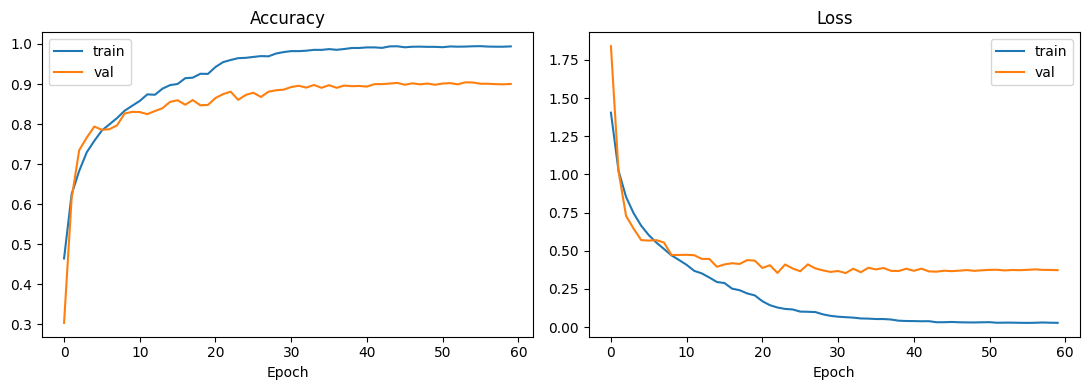

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()


1D CNN test accuracy: 0.8970
              precision    recall  f1-score   support

       relax       0.95      0.96      0.95       467
        open       0.94      0.93      0.94       467
        fist       0.87      0.91      0.89       467
      tripod       0.88      0.88      0.88       468
         key       0.81      0.78      0.79       468
   pronation       0.93      0.94      0.93       467
  supination       0.90      0.87      0.89       468

    accuracy                           0.90      3272
   macro avg       0.90      0.90      0.90      3272
weighted avg       0.90      0.90      0.90      3272



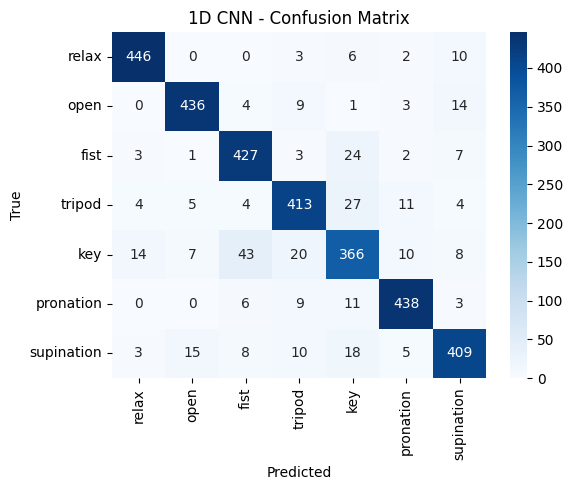

In [ ]:
cnn_loss, cnn_acc = cnn.evaluate(Xc_test, yc_test, verbose=0)
results["1D CNN"] = cnn_acc
print(f"1D CNN test accuracy: {cnn_acc:.4f}")

cnn_pred = le.inverse_transform(np.argmax(cnn.predict(Xc_test, verbose=0), axis=1))
print(classification_report(y_test, cnn_pred, target_names=[GESTURE_NAMES[i] for i in sorted(GESTURE_NAMES)]))
plot_confusion(y_test, cnn_pred, "1D CNN - Confusion Matrix")


## 12. Model comparison

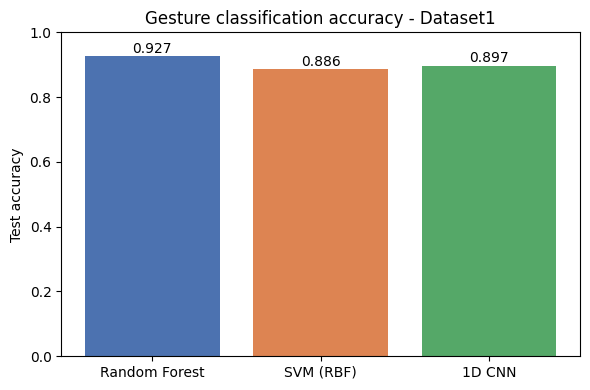

,test_accuracy
Random Forest,0.927262
SVM (RBF),0.886002
1D CNN,0.897005


In [ ]:
plt.figure(figsize=(6, 4))
names, accs = list(results.keys()), list(results.values())
bars = plt.bar(names, accs, color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylim(0, 1.0); plt.ylabel("Test accuracy")
plt.title(f"Gesture classification accuracy - {DATASET_KEY}")
for b, a in zip(bars, accs):
    plt.text(b.get_x()+b.get_width()/2, a+0.01, f"{a:.3f}", ha="center")
plt.tight_layout(); plt.show()

pd.Series(results, name="test_accuracy").to_frame()


## 13. Save models

In [ ]:
import joblib

OUT_DIR = "/content/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

joblib.dump(rf, os.path.join(OUT_DIR, "random_forest.joblib"))
joblib.dump(svm, os.path.join(OUT_DIR, "svm.joblib"))
joblib.dump(scaler, os.path.join(OUT_DIR, "feature_scaler.joblib"))
cnn.save(os.path.join(OUT_DIR, "cnn_model.keras"))
X_feat.assign(label=y, subject=groups).to_csv(os.path.join(OUT_DIR, "features_dataset.csv"), index=False)

shutil_zip = os.path.join("/content", "emg_gesture_models.zip")
with zipfile.ZipFile(shutil_zip, "w") as zf:
    for fn in os.listdir(OUT_DIR):
        zf.write(os.path.join(OUT_DIR, fn), fn)

print("Saved to:", OUT_DIR)
print("Zipped bundle:", shutil_zip)

try:
    from google.colab import files as colab_files
    colab_files.download(shutil_zip)
except ImportError:
    pass


## Notes / next steps

- **Switch dataset**: change `DATASET_KEY` in section 3 to `"Dataset2"` or `"Dataset3"`
  and re-run — everything downstream (channels, filtering band, gestures, CNN input
  shape) adapts automatically. Dataset3 additionally contains *dynamic* transition
  trials (`ConditionIndex/D3_condition_index.csv`) if you want to extend this to
  transition/movement detection.
- **Subject-independent testing**: set `SPLIT_MODE = "group"` in section 9 to train on
  some subjects and test on unseen ones — a harder, more realistic benchmark than the
  default stratified split.
- **Include pFMG**: set `USE_PFMG = True` in section 3 to fuse force-myography with
  sEMG.
- **Tune further**: grid-search SVM/RF hyperparameters, try deeper CNNs, add
  data augmentation (jitter/scaling), or an LSTM/Transformer for longer-range temporal
  context.
